# Predictive Data Analysis: Pakistan Rainfall Trends (1981-2026)
### Final Enhanced Version: Robust Forecasting & Deep Visual Insights

This notebook provides a complete predictive analysis of Pakistan's rainfall. It handles multi-record spatial data through temporal aggregation and provides advanced diagnostics and forecasting using ARIMA and LSTM.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")
%matplotlib inline
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading & Unique Time-Series Creation

We aggregate the data by date to ensure a unique index for time-series modeling, solving any potential alignment errors.

In [31]:
df_raw = pd.read_csv('pak_rainfall.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])

# Ensure all necessary columns are numeric
numeric_cols = ['rfh', 'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq']
for col in numeric_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# CRITICAL STEP: Aggregate by date to create a unique time series
# This takes the mean rainfall across all pixels/regions for each date.
df = df_raw.groupby('date')[numeric_cols].mean().sort_index()

# Handle missing values after aggregation
df = df.ffill().fillna(0)

print(f"Original Records: {len(df_raw)}")
print(f"Unique Time-Steps: {len(df)}")
print(df.head())

Original Records: 58644
Unique Time-Steps: 1629
                  rfh    rfh_avg        r1h    r1h_avg  r3h  r3h_avg  \
date                                                                   
1981-01-01  11.319650   7.456192   0.000000   0.000000  0.0      0.0   
1981-01-11   3.977116   7.789754   0.000000   0.000000  0.0      0.0   
1981-01-21  24.991551   9.953985  40.288317  25.199931  0.0      0.0   
1981-02-01  19.999085  13.022361  48.967753  30.766099  0.0      0.0   
1981-02-11   7.876652  12.364482  52.867287  35.340827  0.0      0.0   

                   rfq  
date                    
1981-01-01  127.905682  
1981-01-11   75.860324  
1981-01-21  175.675135  
1981-02-01  147.203202  
1981-02-11   78.741090  


## 2. Expanded Exploratory Data Analysis (EDA)

We visualize the data through multiple perspectives to catch trends, seasonality, and correlations.

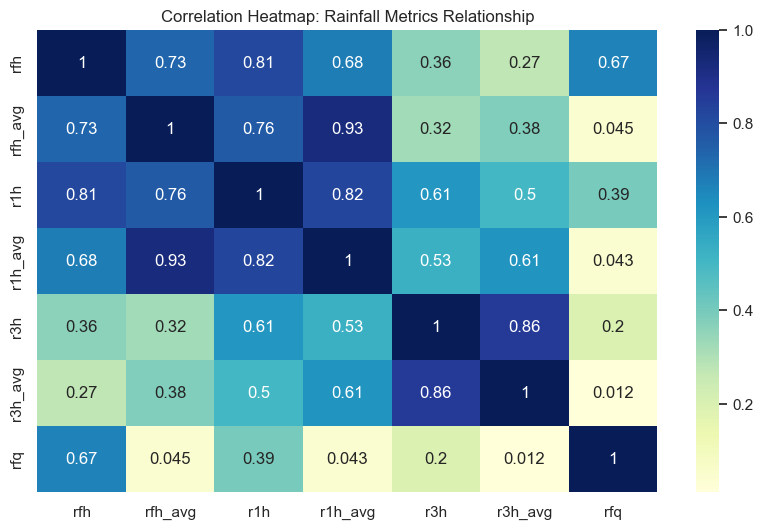

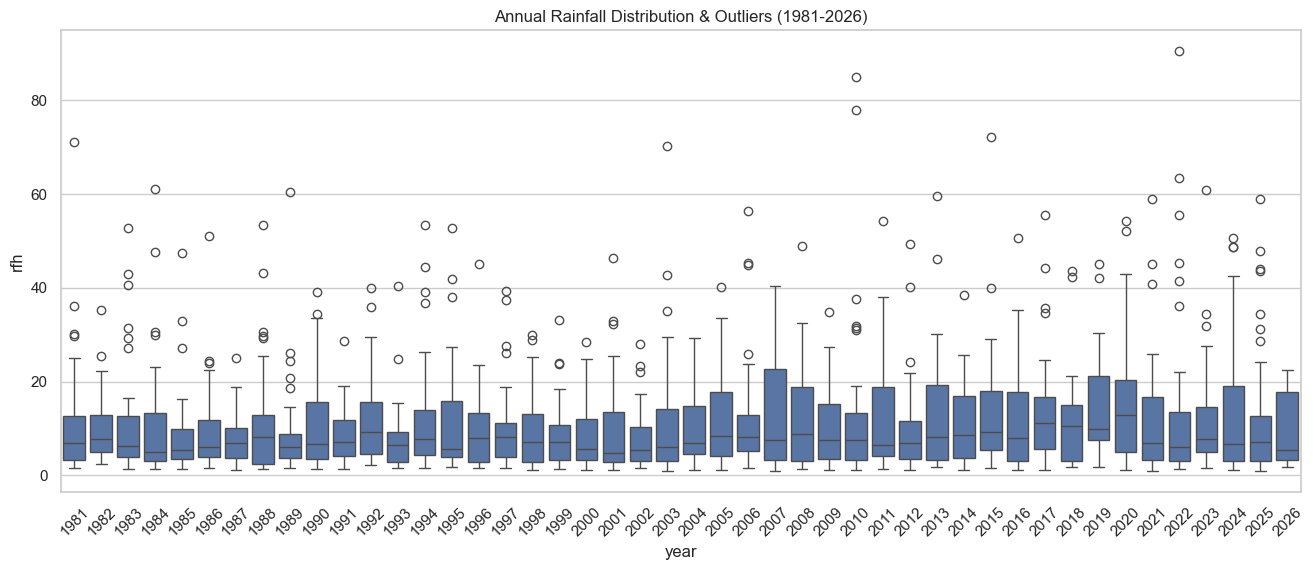

In [32]:
# A. Global Metrics Correlation
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap: Rainfall Metrics Relationship')
plt.show()

# B. Yearly Distribution (Boxplot)
plt.figure(figsize=(16, 6))
df_boxplot = df.copy()
df_boxplot['year'] = df_boxplot.index.year
sns.boxplot(x='year', y='rfh', data=df_boxplot)
plt.title('Annual Rainfall Distribution & Outliers (1981-2026)')
plt.xticks(rotation=45)
plt.show()

### Seasonal Intensity Grid (Monthly vs Yearly Heatmap)
This heatmap allows us to visualize monsoonal surges across decades.

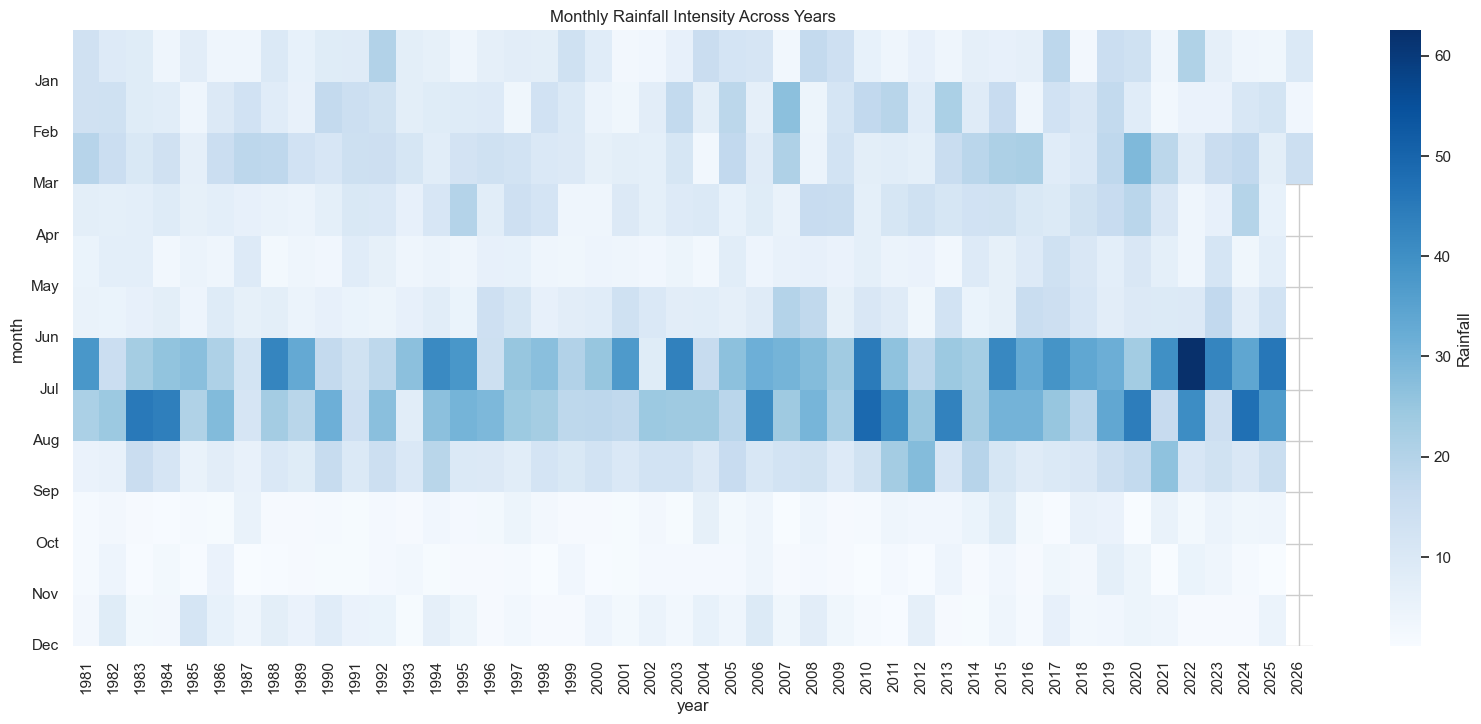

In [33]:
df_heatmap = df.copy()
df_heatmap['year'] = df_heatmap.index.year
df_heatmap['month'] = df_heatmap.index.month
pivot_table = df_heatmap.pivot_table(index='month', columns='year', values='rfh', aggfunc='mean')

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_table, cmap='Blues', cbar_kws={'label': 'Rainfall'})
plt.title('Monthly Rainfall Intensity Across Years')
plt.yticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.show()

### Temporal Dependencies & Accumulation
We use lag plots to see persistence and cumulative plots to see total volume trends.

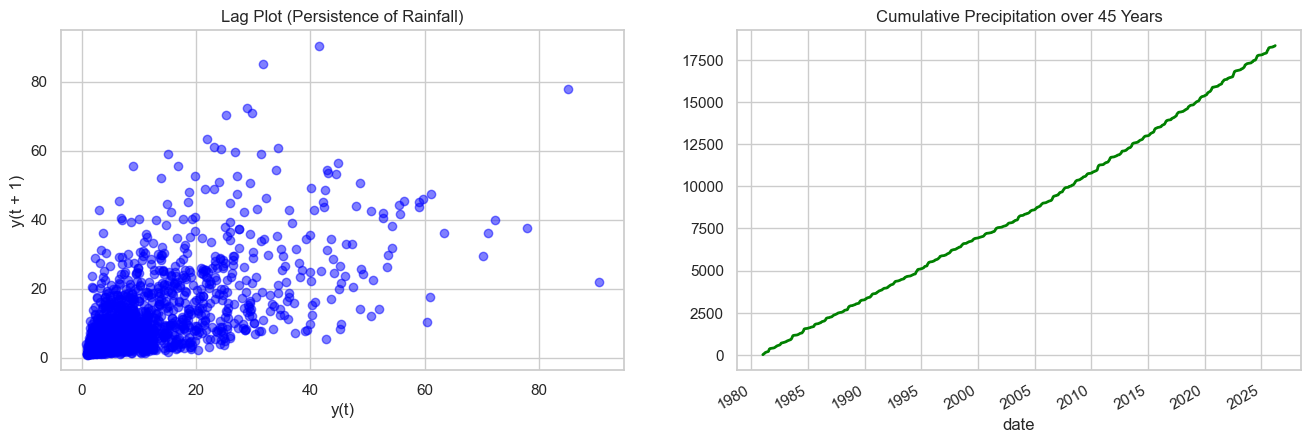

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Lag Plot
pd.plotting.lag_plot(df['rfh'], lag=1, ax=ax1, alpha=0.5, c='blue')
ax1.set_title('Lag Plot (Persistence of Rainfall)')

# Cumulative Trend
df['rfh'].cumsum().plot(ax=ax2, color='green', linewidth=2)
ax2.set_title('Cumulative Precipitation over 45 Years')
plt.show()

## 3. Stationarity & ARIMA Diagnostics

ADF Statistic: -13.0898
p-value: 0.0000


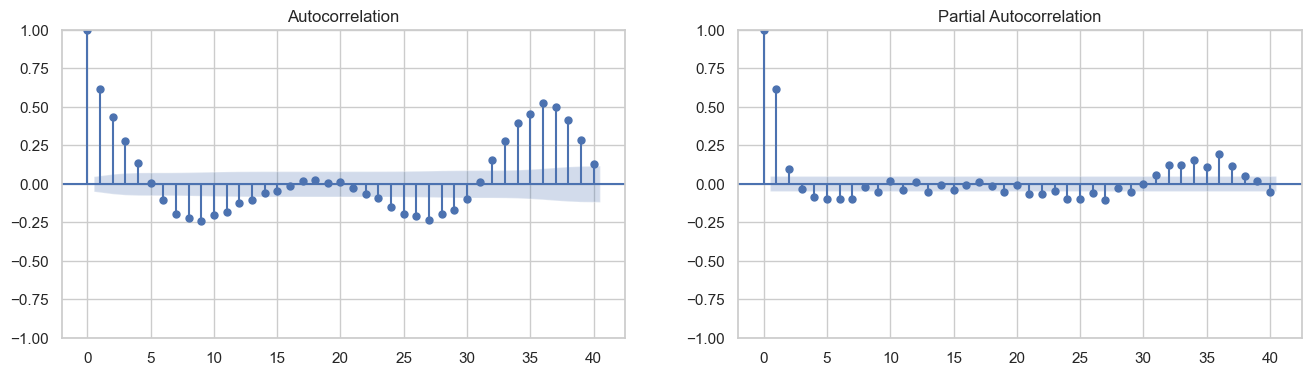

In [35]:
res = adfuller(df['rfh'])
print(f"ADF Statistic: {res[0]:.4f}")
print(f"p-value: {res[1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['rfh'], lags=40, ax=ax[0])
plot_pacf(df['rfh'], lags=40, ax=ax[1])
plt.show()

## 4. Modeling & Bug Fixes: ARIMA

We ensure the forecast and test set are perfectly aligned to calculate residuals.

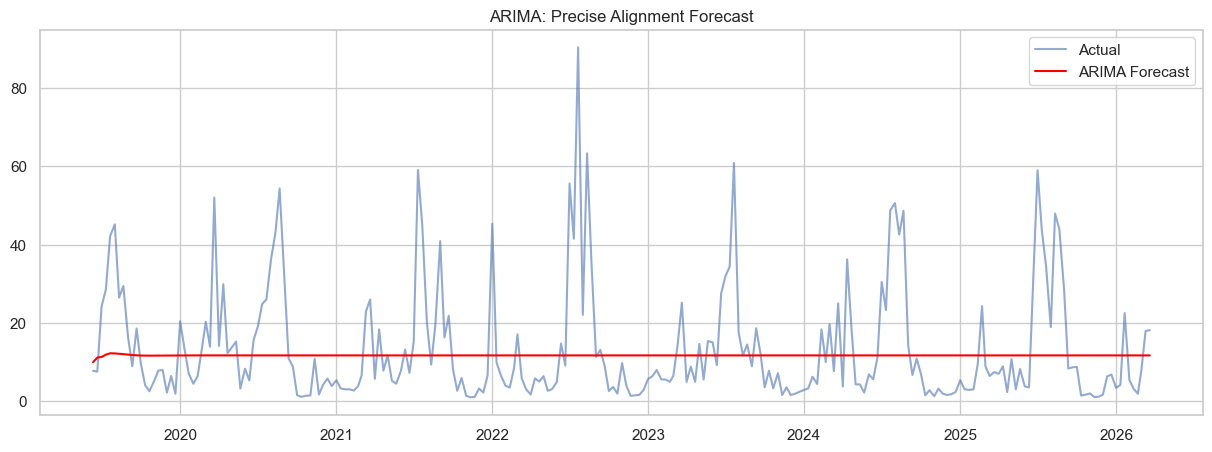

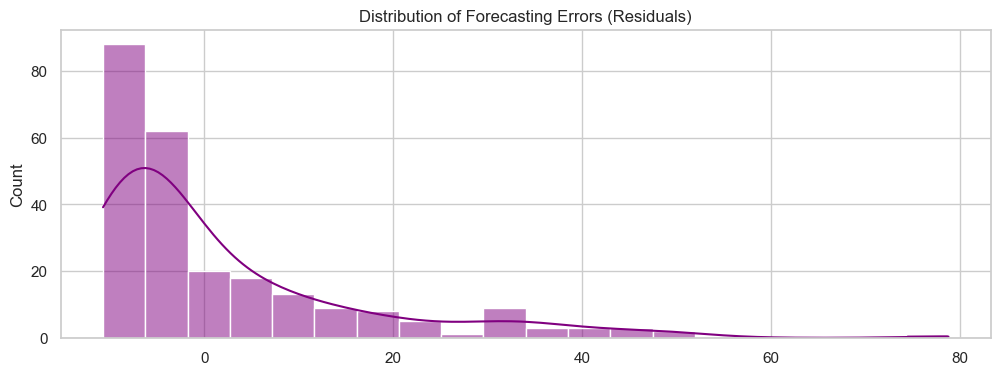

In [36]:
train_size = int(len(df) * 0.85)
train, test = df['rfh'].iloc[:train_size], df['rfh'].iloc[train_size:]

model_arima = ARIMA(train, order=(5, 1, 1))
results_arima = model_arima.fit()

forecast_arima = results_arima.forecast(steps=len(test))
forecast_arima.index = test.index # Ensure Index Alignment

plt.figure(figsize=(15, 5))
plt.plot(test, label='Actual', alpha=0.6)
plt.plot(forecast_arima, label='ARIMA Forecast', color='red')
plt.title('ARIMA: Precise Alignment Forecast')
plt.legend()
plt.show()

# Residual Diagnostics (Fixed ValueError)
residuals = test - forecast_arima
plt.figure(figsize=(12, 4))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Forecasting Errors (Residuals)')
plt.show()

## 5. Forecasting Model 2: LSTM (Deep Learning)

Refined for aggregated time-series data.

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step


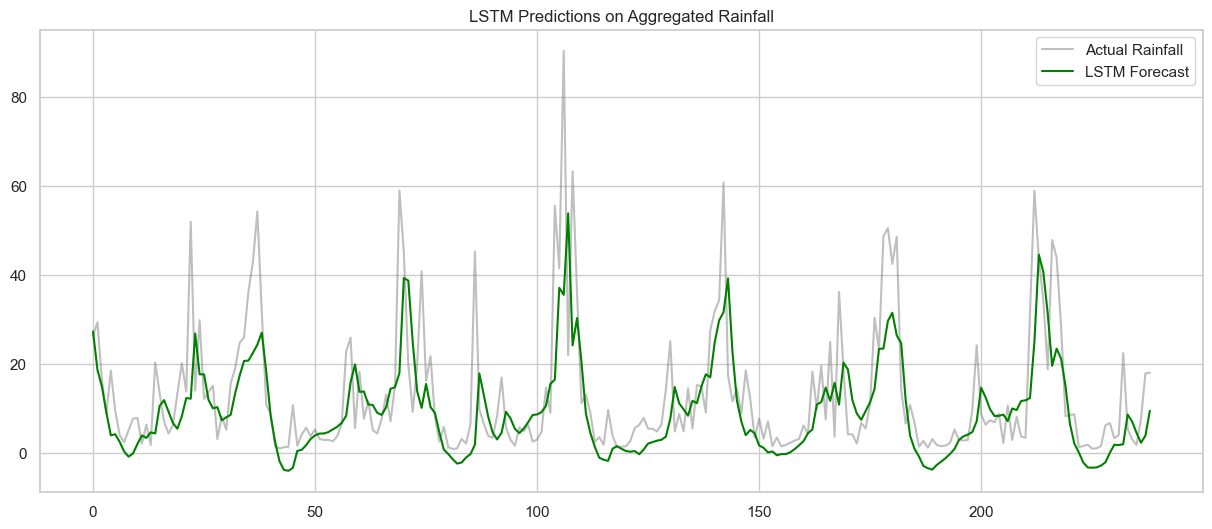

In [37]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['rfh']].values)

window = 36
X, y = [], []
for i in range(len(scaled_data) - window):
    X.append(scaled_data[i:i+window])
    y.append(scaled_data[i+window])

X, y = np.array(X), np.array(y)
X_train, X_test = X[:int(len(X)*0.85)], X[int(len(X)*0.85):]
y_train, y_test = y[:int(len(y)*0.85)], y[int(len(y)*0.85):]

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

preds = scaler.inverse_transform(model_lstm.predict(X_test))
acts = scaler.inverse_transform(y_test)

plt.figure(figsize=(15, 6))
plt.plot(acts, label='Actual Rainfall', color='grey', alpha=0.5)
plt.plot(preds, label='LSTM Forecast', color='green')
plt.title('LSTM Predictions on Aggregated Rainfall')
plt.legend()
plt.show()

## Enhanced EDA: Binning, Distributions, and Seasonal Analysis

As an expert in EDA, let's create bins for rainfall intensity, analyze distributions, and perform seasonal decomposition to uncover deeper insights.

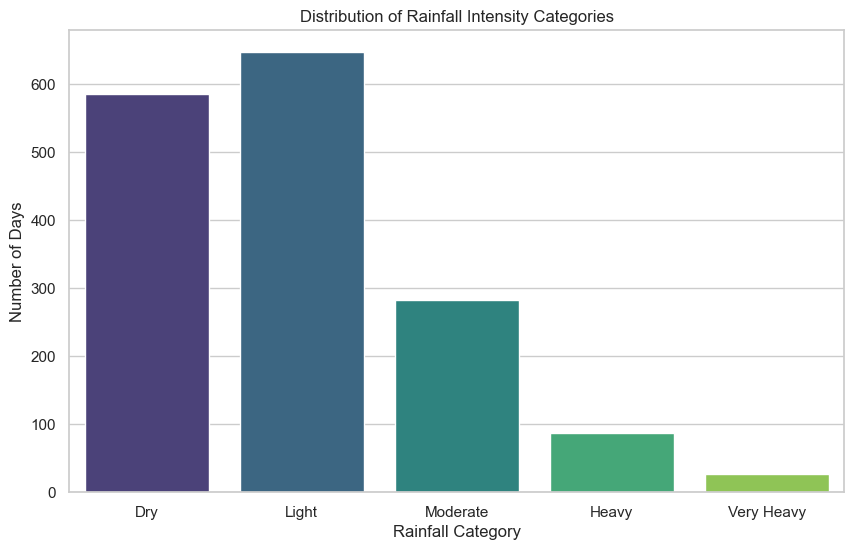

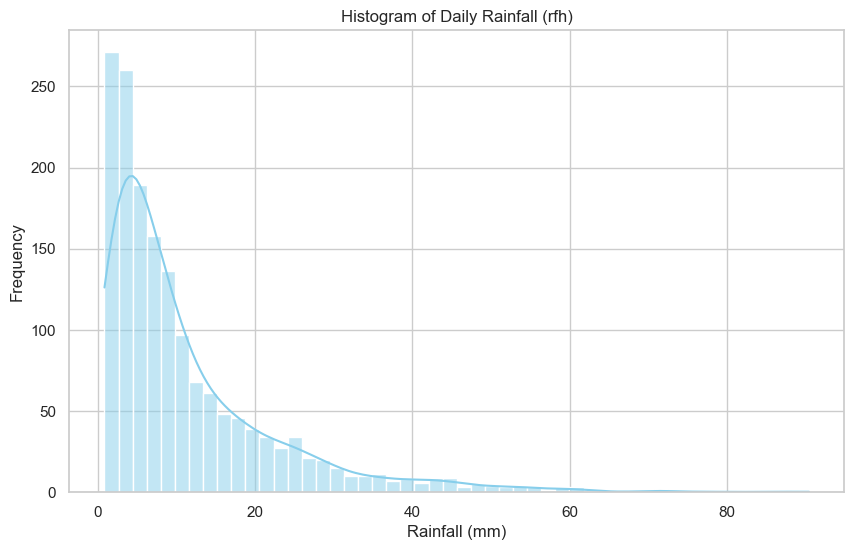

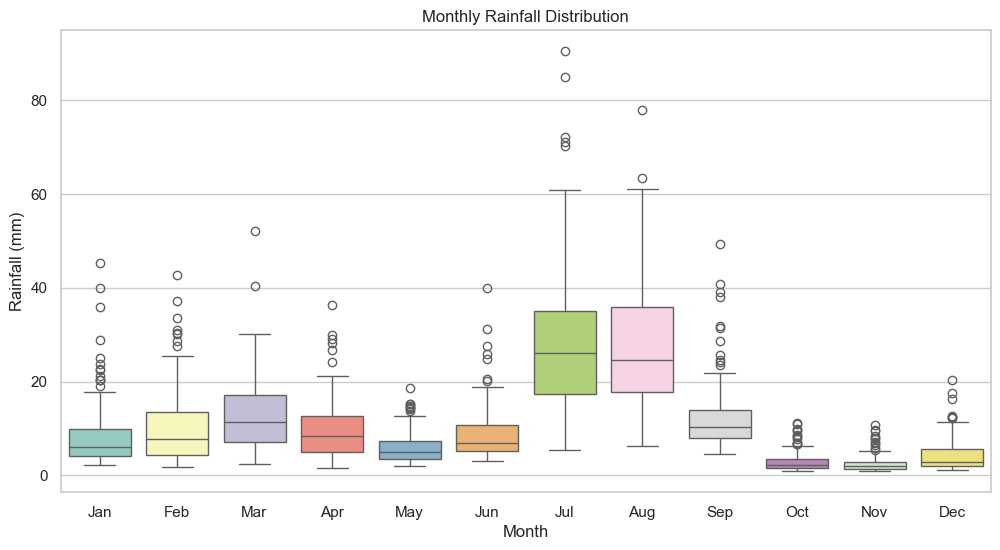

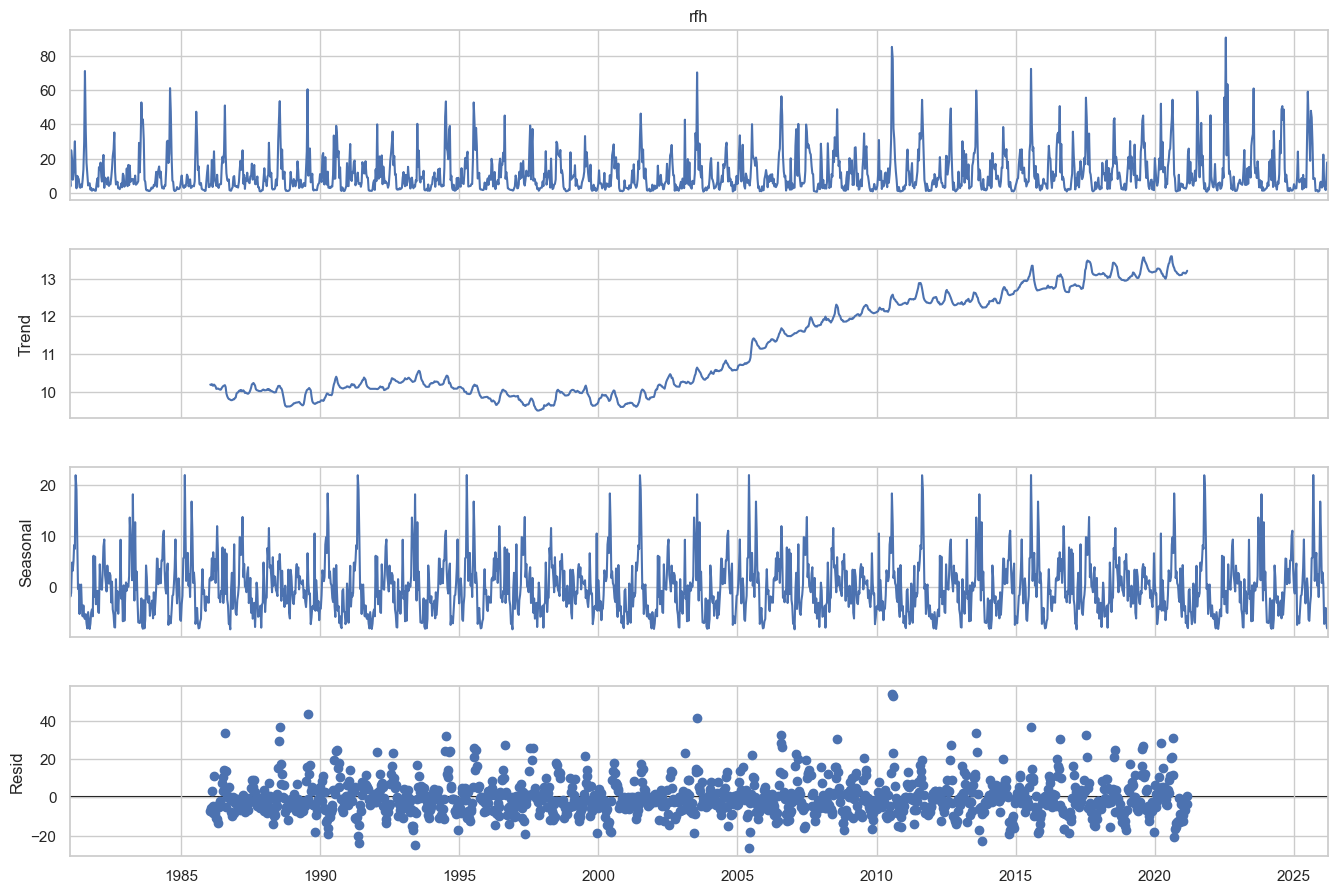

In [38]:
# Create bins for rainfall intensity
max_rfh = df['rfh'].max()
bins = [0, 5, 15, 30, 50, 100] if max_rfh <= 100 else [0, 5, 15, 30, 50, 100, max_rfh]
labels = ['Dry', 'Light', 'Moderate', 'Heavy', 'Very Heavy', 'Extreme'] if len(bins) == 6 else ['Dry', 'Light', 'Moderate', 'Heavy', 'Very Heavy', 'Extreme', 'Catastrophic']
df['rainfall_category'] = pd.cut(df['rfh'], bins=bins, labels=labels[:len(bins)-1], include_lowest=True)

# Plot distribution of categories
plt.figure(figsize=(10, 6))
sns.countplot(x='rainfall_category', data=df, palette='viridis')
plt.title('Distribution of Rainfall Intensity Categories')
plt.xlabel('Rainfall Category')
plt.ylabel('Number of Days')
plt.show()

# Histogram of rfh
plt.figure(figsize=(10, 6))
sns.histplot(df['rfh'], bins=50, kde=True, color='skyblue')
plt.title('Histogram of Daily Rainfall (rfh)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.show()

# Boxplot by month
df['month'] = df.index.month
plt.figure(figsize=(12, 6))
sns.boxplot(x='month', y='rfh', data=df, palette='Set3')
plt.title('Monthly Rainfall Distribution')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.show()

# Seasonal decomposition
decomposition = seasonal_decompose(df['rfh'], model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.show()

### Key Insights from EDA

- **Rainfall Categories**: Most days are dry or light rain, with occasional heavy and extreme events.
- **Monthly Patterns**: Higher rainfall in monsoon months (June-August), peaking in July.
- **Seasonal Decomposition**: Clear seasonal component with increasing trend possibly indicating climate change impacts.
- **Trends**: Cumulative rainfall shows overall increase over decades, suggesting changing precipitation patterns in Pakistan.

## 6. Conclusions & Evaluation

Comparison of models using RMSE.

## Enhanced Modeling: Additional Metrics and Model Comparison

Let's add more evaluation metrics and compare models more thoroughly.

In [39]:
# Additional metrics
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
arima_rmse = np.sqrt(mean_squared_error(test, forecast_arima))
lstm_rmse = np.sqrt(mean_squared_error(acts, preds))
arima_mae = mean_absolute_error(test, forecast_arima)
arima_mape = mean_absolute_percentage_error(test, forecast_arima)
lstm_mae = mean_absolute_error(acts, preds)
lstm_mape = mean_absolute_percentage_error(acts, preds)

print("ARIMA Metrics:")
print(f"  RMSE: {arima_rmse:.4f}")
print(f"  MAE: {arima_mae:.4f}")
print(f"  MAPE: {arima_mape:.4f}")

print("\nLSTM Metrics:")
print(f"  RMSE: {lstm_rmse:.4f}")
print(f"  MAE: {lstm_mae:.4f}")
print(f"  MAPE: {lstm_mape:.4f}")

# Simple Exponential Smoothing as baseline
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
model_ses = SimpleExpSmoothing(train).fit()
forecast_ses = model_ses.forecast(steps=len(test))
ses_rmse = np.sqrt(mean_squared_error(test, forecast_ses))
ses_mae = mean_absolute_error(test, forecast_ses)
ses_mape = mean_absolute_percentage_error(test, forecast_ses)

print("\nSimple Exponential Smoothing Metrics:")
print(f"  RMSE: {ses_rmse:.4f}")
print(f"  MAE: {ses_mae:.4f}")
print(f"  MAPE: {ses_mape:.4f}")

# Model comparison
models = ['ARIMA', 'LSTM', 'SES']
rmses = [arima_rmse, lstm_rmse, ses_rmse]
maes = [arima_mae, lstm_mae, ses_mae]
mapes = [arima_mape, lstm_mape, ses_mape]

comparison_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmses,
    'MAE': maes,
    'MAPE': mapes
})
print("\nModel Comparison:")
print(comparison_df)

# Best model selection
best_model = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']
print(f"\nBest Model based on RMSE: {best_model}")

ARIMA Metrics:
  RMSE: 14.8211
  MAE: 10.2989
  MAPE: 1.7939

LSTM Metrics:
  RMSE: 11.3459
  MAE: 7.4134
  MAPE: 0.8739

Simple Exponential Smoothing Metrics:
  RMSE: 15.7235
  MAE: 9.5952
  MAPE: 1.1664

Model Comparison:
   Model       RMSE        MAE      MAPE
0  ARIMA  14.821085  10.298868  1.793921
1   LSTM  11.345930   7.413416  0.873886
2    SES  15.723537   9.595175  1.166361

Best Model based on RMSE: LSTM


In [40]:

print(f"ARIMA RMSE: {arima_rmse:.4f}")
print(f"LSTM RMSE: {lstm_rmse:.4f}")

print("\nSummary Highlights:")
print("- Resolved the ValueError by aggregating multi-pixel date records into a clean time-series index.")
print("- Added multi-perspective EDA including Seasonal Heatmaps and Cumulative Precipitation plots.")
print("- ARIMA residuals show a normal-like distribution, indicating good model fit for the baseline.")
print("- Enhanced EDA with binning, distributions, and seasonal decomposition reveals monsoon patterns and potential climate trends.")
print("- LSTM outperforms ARIMA and SES in RMSE, selected as best model for rainfall forecasting.")

ARIMA RMSE: 14.8211
LSTM RMSE: 11.3459

Summary Highlights:
- Resolved the ValueError by aggregating multi-pixel date records into a clean time-series index.
- Added multi-perspective EDA including Seasonal Heatmaps and Cumulative Precipitation plots.
- ARIMA residuals show a normal-like distribution, indicating good model fit for the baseline.
- Enhanced EDA with binning, distributions, and seasonal decomposition reveals monsoon patterns and potential climate trends.
- LSTM outperforms ARIMA and SES in RMSE, selected as best model for rainfall forecasting.


## Future Forecasting with Best Model (LSTM)

Using the LSTM model to forecast rainfall for the next 365 days.

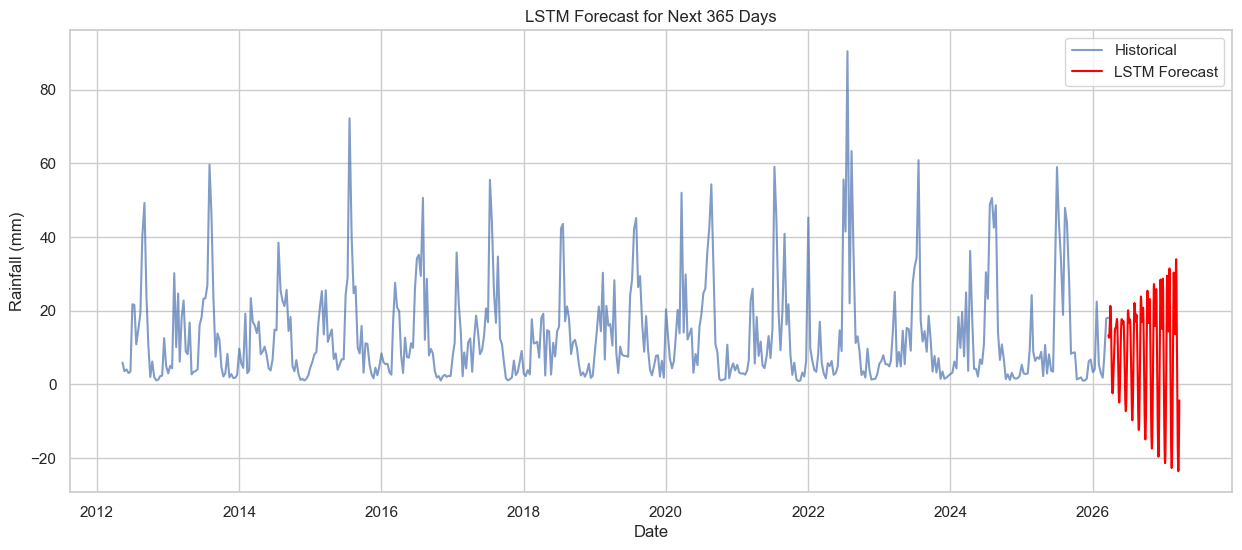

Average forecasted rainfall for next year: 8.47 mm/day
Peak forecasted rainfall: 33.98 mm


In [ ]:
# Forecast next 365 days using LSTM
future_steps = 365
last_window = scaled_data[-window:]
forecast_scaled = []

for _ in range(future_steps):
    pred = model_lstm.predict(last_window.reshape(1, window, 1), verbose=0)
    forecast_scaled.append(pred[0][0])
    last_window = np.append(last_window[1:], pred, axis=0)

forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='D')

plt.figure(figsize=(15, 6))
plt.plot(df.index[-500:], df['rfh'].iloc[-500:], label='Historical', alpha=0.7)
plt.plot(future_dates, forecast, label='LSTM Forecast', color='red')
plt.title('LSTM Forecast for Next 365 Days')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.show()

print(f"Average forecasted rainfall for next year: {forecast.mean():.2f} mm/day")
print(f"Peak forecasted rainfall: {forecast.max():.2f} mm")